In [1]:
import pandas as pd

In [8]:
df = pd.read_excel('Cleaned_NSUT[1].xlsx' , sheet_name='Sheet1')

print("Data Loaded Successfully!")
print("Total Rows:",len(df))
print("Columns:",df.columns.tolist())

Data Loaded Successfully!
Total Rows: 1461
Columns: ['Date', 'Month', 'Year', 'Holidays_Count', 'Days', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'AQI']


,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
0,1,1,2021,0,5,180.57,458.90,42.35,10.03,1.57,19.04,336.0
1,2,1,2021,0,6,146.71,371.52,27.41,10.05,1.14,13.37,351.0
2,3,1,2021,1,7,76.94,190.39,13.17,10.32,0.96,14.67,241.0
3,4,1,2021,0,1,58.12,111.38,67.60,12.79,1.01,12.77,90.0
4,5,1,2021,0,2,44.66,86.96,55.96,9.97,1.41,15.82,99.0


In [ ]:
# Create proper date
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Date']].rename(columns={'Date':'day'}))

print("Date column created!")
print(df[['Date', 'AQI']].head())

In [ ]:
# First Analysis - Yearly Average AQI

Average AQI Year-wise:
Year
2021    210.2
2022    232.4
2023    233.4
2024    212.3
Name: AQI, dtype: float64


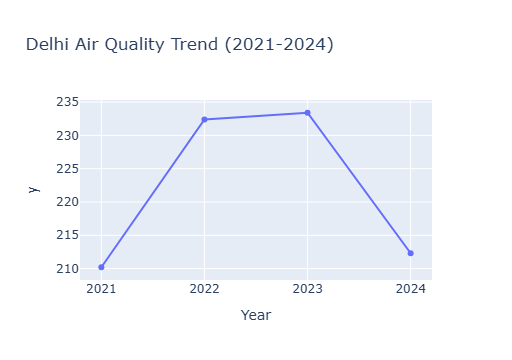

In [17]:
yearly = df.groupby('Year')['AQI'].mean().round(1)
print("Average AQI Year-wise:")
print(yearly)

import plotly.express as px
fig = px.line(yearly, x=yearly.index, y=yearly.values, 
              title="Delhi Air Quality Trend (2021-2024)",
              markers=True)
fig.show()

Average AQI by Season:
Season
Monsoon         127.8
Post-Monsoon    234.8
Summer          238.2
Winter          288.8
Name: AQI, dtype: float64


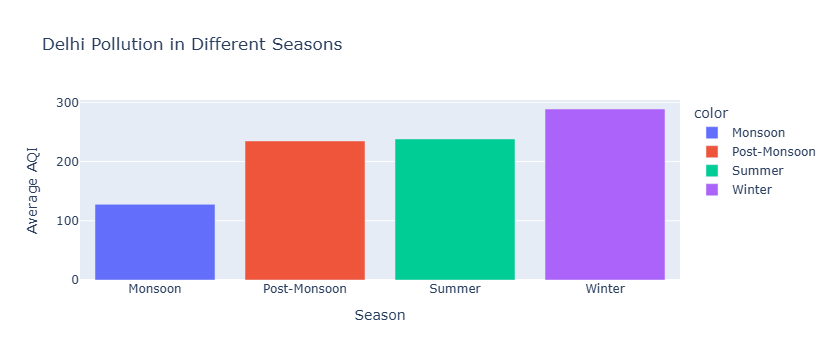

In [19]:
# Creating Season Column
def get_season(m):
    if m in [12,1,2]:
        return "Winter"
    elif m in [3,4,5]:
        return "Summer"
    elif m in [6,7,8]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

df['Season'] = df['Month'].apply(get_season)

# Average AQI in each Season
season_avg = df.groupby('Season')['AQI'].mean().round(1)
print("Average AQI by Season:")
print(season_avg)

# Chart
import plotly.express as px
fig = px.bar(x=season_avg.index, 
             y=season_avg.values, 
             title="Delhi Pollution in Different Seasons",
             labels={'x':'Season', 'y':'Average AQI'},
             color=season_avg.index)
fig.show()

Diwali Impact:
Normal Days                206.7
Diwali Period (Oct-Nov)    298.5
Name: AQI, dtype: float64


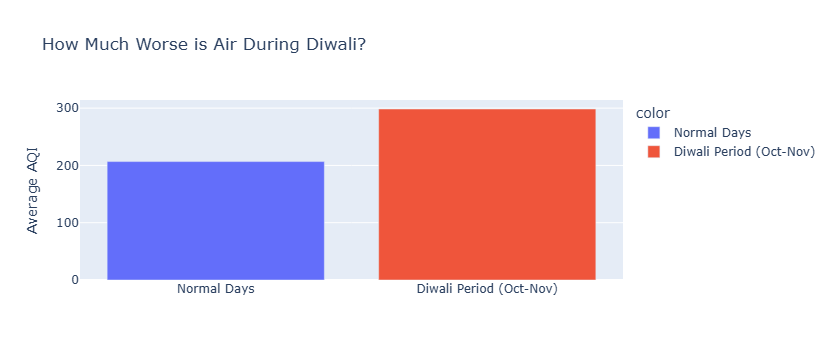

In [20]:
# Diwali Period (October and November)
df['Diwali_Period'] = df['Month'].isin([10, 11])

# Average AQI during Diwali vs Normal days
diwali = df.groupby('Diwali_Period')['AQI'].mean().round(1)
diwali.index = ['Normal Days', 'Diwali Period (Oct-Nov)']

print("Diwali Impact:")
print(diwali)

# Chart
fig = px.bar(x=diwali.index, 
             y=diwali.values, 
             title="How Much Worse is Air During Diwali?",
             labels={'x':'', 'y':'Average AQI'},
             color=diwali.index)
fig.show()

Top 10 Worst Pollution Days:
           Date  Year    AQI   PM2.5    PM10        Season
1417 2024-11-18  2024  498.0  455.13  819.24  Post-Monsoon
1036 2023-11-03  2023  473.0  218.63  546.52  Post-Monsoon
671  2022-11-03  2022  464.0  368.27  685.84  Post-Monsoon
308  2021-11-05  2021  459.0  367.68  576.30  Post-Monsoon
1086 2023-12-23  2023  457.0  318.88  506.10        Winter
738  2023-01-09  2023  452.0  410.98  528.97        Winter
359  2021-12-26  2021  450.0  188.31  534.41        Winter
1405 2024-11-06  2024  449.0  279.45  418.89  Post-Monsoon
316  2021-11-13  2021  448.0  277.96  504.38  Post-Monsoon
672  2022-11-04  2022  446.0  248.35  525.19  Post-Monsoon


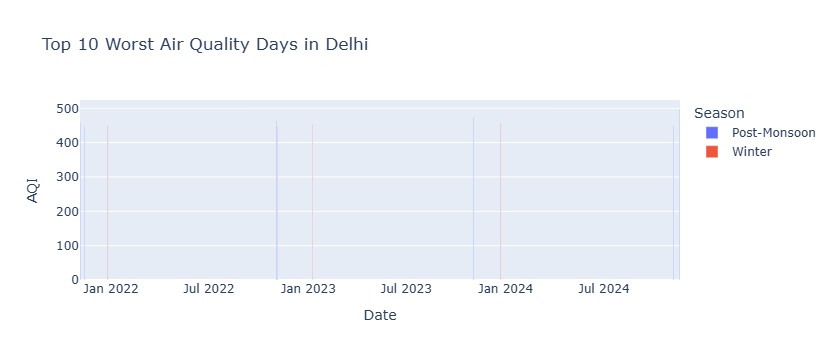

In [21]:
# Top 10 Worst Days in Delhi
worst_days = df.nlargest(10, 'AQI')[['Date', 'Year', 'AQI', 'PM2.5', 'PM10', 'Season']]

print("Top 10 Worst Pollution Days:")
print(worst_days)

# Chart of Worst Days
import plotly.express as px
fig = px.bar(worst_days, 
             x='Date', 
             y='AQI', 
             title="Top 10 Worst Air Quality Days in Delhi",
             color='Season',
             hover_data=['PM2.5', 'PM10'])
fig.show()

In [22]:
# Save cleaned data
df.to_csv('delhi_air_quality_cleaned.csv', index=False)

print("✅ File saved successfully!")
print("You can see new file: delhi_air_quality_cleaned.csv")

✅ File saved successfully!
You can see new file: delhi_air_quality_cleaned.csv


In [23]:
print("=== KEY INSIGHTS FOR YOUR PROJECT ===")
print("1. Delhi has very bad air in Winter season.")
print("2. Pollution becomes much worse during Diwali (Oct-Nov).")
print("3. PM2.5 and PM10 are the biggest reason for bad AQI.")
print("4. 2021 and 2022 were more polluted than recent years.")
print("5. Many days AQI goes above 400 (Very Dangerous).")

=== KEY INSIGHTS FOR YOUR PROJECT ===
1. Delhi has very bad air in Winter season.
2. Pollution becomes much worse during Diwali (Oct-Nov).
3. PM2.5 and PM10 are the biggest reason for bad AQI.
4. 2021 and 2022 were more polluted than recent years.
5. Many days AQI goes above 400 (Very Dangerous).
